# 01. 에이전트 테스트 전략 (Agent Testing)

> 에이전트 테스트의 가장 큰 적은 **LLM 호출 비용·비결정성**이에요. `GenericFakeChatModel`, `InMemorySaver`, `interrupt_after` 로 결정적이고 빠른 단위 테스트를 만들어요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **단위 테스트(Unit Test)**를 `GenericFakeChatModel`로 작성해 API 비용 없이 에이전트 로직을 검증할 수 있어요
2. **통합 테스트(Integration Test)**를 실제 LLM API로 실행하고 pytest 마커로 분리해 비용을 제어할 수 있어요
3. **개별 노드(Node) 테스트**를 그래프에서 분리해 독립적으로 검증할 수 있어요
4. **부분 실행(Partial Execution)**으로 `update_state` + `interrupt_after`를 활용해 특정 노드까지만 실행해 상태를 검사할 수 있어요
5. pytest 설정 파일로 통합 테스트를 기본 실행에서 제외해 비용 효율적인 CI/CD 파이프라인을 구성할 수 있어요

## 사전 지식

- Part 11까지의 에이전트 개발 경험
- LangGraph의 `StateGraph`, `create_agent` 기본 사용법
- pytest 기초 (테스트 함수 작성, 실행 방법)

## 왜 에이전트 테스트가 필요한가?

건물을 지을 때 **안전 검사**를 하지 않으면 어떻게 될까요? 작은 균열이 나중에 건물 전체를 무너뜨릴 수 있어요. 에이전트도 마찬가지예요. 테스트 없이 배포하면 예상치 못한 도구 호출, 잘못된 상태 전환, 비용 폭발 같은 문제가 프로덕션에서 터져요.

> 🎯 **강의 포인트**: 에이전트 테스트는 건물의 안전 검사와 같아요. **기초(단위 테스트)**가 튼튼해야 **구조(통합 테스트)**가 안전하고, 최종적으로 **입주 검사(평가)**를 통과해야 실제로 사용할 수 있어요.

## 핵심 용어 정의

LangChain 공식 문서([Test 가이드](https://docs.langchain.com/oss/python/langchain/test/index.md))는 에이전트 테스트를 **세 가지 접근 방식(approaches)**으로 구분해요. 이 용어들은 이후 노트북 전체에서 반복되므로 먼저 짚고 갑니다.

| 용어 | 공식 정의 | 무엇을 검증하나? | 외부 API 호출 |
|------|-----------|-----------------|--------------|
| **Unit Test** | Mock chat models and in-memory persistence로 에이전트 로직을 테스트 | 노드/상태 변환/엣지 라우팅 등 결정적 로직 | ✗ |
| **Integration Test** | 실제 LLM API로 실행하며 컴포넌트 간 연결을 검증 | 스키마·크리덴셜·성능 등 실제 모델과의 상호작용 | ✓ |
| **Evals(Evaluation)** | 결정적 매칭 또는 LLM 판단으로 실행 시퀀스를 "채점" | 품질·정확도·궤적(trajectory) — 점수 기반 | ✓ (보통) |

> 🔑 **Test vs Eval 구분**: 테스트는 **pass/fail**(버그 찾기), 평가는 **0.0~1.0 점수**(품질 측정)이에요. 단위·통합 테스트는 이 노트북에서, 평가는 `02-Agent-Evaluation`에서 다뤄요.

> 🔑 **Trajectory(궤적)**: 에이전트가 문제를 푸는 동안 거친 **도구 호출·인자·메시지의 전체 시퀀스**. 최종 답변만 보는 게 아니라 "어떻게 도달했는지"까지 검증할 때 사용해요. 자세한 평가는 다음 노트북에서 다뤄요.

## 에이전트 테스트의 3단계 전략

에이전트는 일반적인 함수와 다르게 **비결정적(non-deterministic)**이에요. LLM이 매번 다른 응답을 생성하고, 외부 API를 호출하며, 비용이 발생해요. 그래서 체계적인 테스트 전략이 필요해요.

```mermaid
flowchart TD
    A[에이전트 테스트<br/>Agent Testing] --> B[1단계: 단위 테스트<br/>Unit Test]
    A --> C[2단계: 통합 테스트<br/>Integration Test]
    A --> D[3단계: 평가<br/>Evals]

    B --> B1[GenericFakeChatModel<br/>가짜 모델 사용]
    B --> B2[InMemorySaver<br/>테스트용 체크포인터]
    B --> B3[개별 노드 격리 테스트]

    C --> C1[실제 LLM API 호출]
    C --> C2[pytest.mark.integration<br/>마커로 분리]
    C --> C3[구조적 검증<br/>타입/도구명/인자]

    D --> D1[LangSmith Evals]
    D --> D2[궤적 평가<br/>Trajectory]
    D --> D3[LLM-as-Judge]

    style B fill:#d4edda,stroke:#28a745,color:#155724
    style C fill:#cce5ff,stroke:#007bff,color:#004085
    style D fill:#fff3cd,stroke:#ffc107,color:#856404
    style A fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

### 각 단계 비교

| 단계 | 비유 | 도구 | 비용 | 속도 | 확인 가능한 것 |
|------|------|------|------|------|----------------|
| **단위 테스트** | 기초 검사 | `GenericFakeChatModel` | 무료 | 빠름 (ms) | 로직, 상태 변환, 노드 동작 |
| **통합 테스트** | 구조 검사 | 실제 LLM API | 유료 | 느림 (초~분) | 실제 모델 동작, 도구 선택, 응답 품질 |
| **평가** | 입주 검사 | LangSmith | 유료 | 가장 느림 | 궤적 품질, 최종 답변 품질 |

> 🔑 **핵심 개념**: 단위 테스트를 가장 많이, 통합 테스트를 적당히, 평가는 릴리즈 전에 실행하는 **테스트 피라미드** 전략을 따라요. 대부분의 버그는 단위 테스트에서 발견할 수 있어요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# ---------------------------------------------------
# 테스트에서 사용할 샘플 에이전트 정의
# ---------------------------------------------------
# LangGraph V1 에이전트 생성에 필요한 패키지를 가져와요
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel


# ---------------------------------------------------
# FakeChatModelWithTools: 단위 테스트용 가짜 모델
# ---------------------------------------------------
# GenericFakeChatModel은 bind_tools()를 구현하지 않아요.
# create_agent()에 tools를 전달하면 bind_tools()가 호출되는데,
# 이를 지원하도록 서브클래스를 만들어요.
class FakeChatModelWithTools(GenericFakeChatModel):
    """도구 바인딩을 지원하는 테스트용 가짜 모델이에요.
    
    GenericFakeChatModel을 상속하여 bind_tools()가 자기 자신을 반환하도록 해요.
    실제 도구를 모델에 바인딩하지 않고, 미리 정의한 응답을 순서대로 반환해요.
    """
    def bind_tools(self, tools, **kwargs):
        # 자신을 반환해요 (도구 바인딩 무시, 미리 정의한 응답 사용)
        return self


# ---------------------------------------------------
# 테스트용 도구 정의
# ---------------------------------------------------
# 이 도구들은 테스트 전반에서 사용할 거예요
@tool
def get_weather(city: str) -> str:
    """도시의 현재 날씨를 조회해요."""
    # 실제로는 날씨 API를 호출하겠지만, 테스트용으로 고정값을 반환해요
    weather_data = {
        "서울": "맑음, 18°C",
        "부산": "흐림, 22°C",
        "제주": "비, 20°C",
    }
    return weather_data.get(city, f"{city}: 데이터 없음")


@tool
def calculate(expression: str) -> str:
    """수학 계산식을 평가해요."""
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"


# 도구 목록
tools = [get_weather, calculate]

# 도구 정의 완료:
for t in tools:
    print(f"  - {t.name}: {t.description}")
# FakeChatModelWithTools 사용 준비 완료

  - get_weather: 도시의 현재 날씨를 조회해요.
  - calculate: 수학 계산식을 평가해요.


## 1. 단위 테스트: GenericFakeChatModel

단위 테스트(Unit Test)의 핵심은 **외부 의존성을 제거**하는 거예요. LLM API 없이 에이전트의 로직만 테스트하려면 `GenericFakeChatModel`을 사용해요.

이것은 마치 **연극 리허설**과 같아요. 진짜 관객(LLM API) 없이 대본(스크립트된 응답)으로 연습하면서, 배우(에이전트)가 올바른 동선(로직)으로 움직이는지 확인하는 거예요.

### GenericFakeChatModel이란?

`GenericFakeChatModel`은 실제 LLM 대신 미리 정의한 **스크립트된 응답(scripted responses)**을 순서대로 반환하는 가짜 모델이에요.

```mermaid
flowchart LR
    A[테스트 코드] --> B[GenericFakeChatModel]
    B --> C{응답 큐}
    C --> D[첫 번째 호출 → 응답1]
    C --> E[두 번째 호출 → 응답2]
    C --> F[세 번째 호출 → 응답3]

    style B fill:#d4edda,stroke:#28a745,color:#155724
    style A fill:#cce5ff,stroke:#007bff,color:#004085
```

> 🔑 **핵심 개념**: `GenericFakeChatModel`은 `messages` 파라미터에 응답 리스트를 받아요. 각 응답은 `AIMessage`이며, `tool_calls`를 포함시켜 도구 호출을 시뮬레이션할 수도 있어요. 응답이 소진되면 `StopIteration` 에러가 발생해요.

> ⚠️ **자주 하는 실수**: 테스트마다 새로운 `GenericFakeChatModel` 인스턴스를 생성해야 해요. 응답 큐는 소모성이라서 한 번 사용하면 없어지거든요. 같은 인스턴스를 재사용하면 두 번째 테스트에서 `StopIteration` 에러가 발생해요.

In [3]:
# ---------------------------------------------------
# GenericFakeChatModel 기본 사용법
# ---------------------------------------------------
# 가짜 모델 임포트: API 없이 스크립트된 응답을 반환해요
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langchain.messages import HumanMessage, AIMessage


# 가짜 모델 생성: 순서대로 반환할 응답을 미리 정의해요
fake_model = GenericFakeChatModel(
    messages=iter([
        AIMessage(content="안녕하세요! 무엇을 도와드릴까요?"),  # 첫 번째 호출 응답
        AIMessage(content="좋은 질문이에요!"),                   # 두 번째 호출 응답
    ])
)

# 첫 번째 호출
response1 = fake_model.invoke([HumanMessage(content="안녕")])
print("첫 번째 응답:", response1.content)

# 두 번째 호출
response2 = fake_model.invoke([HumanMessage(content="질문이 있어요")])
print("두 번째 응답:", response2.content)

# ※ create_agent()에 tools를 전달할 때는 FakeChatModelWithTools를 사용해요
#   (GenericFakeChatModel은 bind_tools()를 지원하지 않아요)

첫 번째 응답: 안녕하세요! 무엇을 도와드릴까요?
두 번째 응답: 좋은 질문이에요!


In [4]:
# ---------------------------------------------------
# 도구 호출(Tool Call)을 포함한 가짜 응답
# ---------------------------------------------------
# 에이전트가 도구를 호출하는 상황을 시뮬레이션해요
from langchain.messages import AIMessage


# tool_calls를 포함한 AIMessage: 도구 호출을 시뮬레이션해요
tool_call_response = AIMessage(
    content="",  # 도구 호출 시 content는 보통 비어있어요
    tool_calls=[
        {
            "id": "call_001",        # 고유 ID (임의 값)
            "name": "get_weather",   # 호출할 도구 이름
            "args": {"city": "서울"}, # 도구에 전달할 인자
            "type": "tool_call",
        }
    ]
)

# 도구 호출 후 최종 응답
final_response = AIMessage(content="서울의 날씨는 맑음, 18°C에요.")

# 가짜 모델에 두 응답을 순서대로 설정해요
fake_model_with_tool = GenericFakeChatModel(
    messages=iter([tool_call_response, final_response])
)

# 첫 번째 호출: 도구 호출 응답
response = fake_model_with_tool.invoke([HumanMessage(content="서울 날씨 알려줘")])
print("첫 번째 응답 타입:", type(response).__name__)
print("도구 호출 목록:", response.tool_calls)

첫 번째 응답 타입: AIMessage
도구 호출 목록: [{'name': 'get_weather', 'args': {'city': '서울'}, 'id': 'call_001', 'type': 'tool_call'}]


## 2. InMemorySaver: 테스트용 체크포인터

테스트에서 체크포인터가 필요할 때는 항상 `InMemorySaver`를 사용해요. 각 테스트마다 **새로운 인스턴스**를 생성해야 테스트 간 상태 오염을 막을 수 있어요.

> 💡 **실무 팁**: `InMemorySaver`는 메모리 내에서만 동작하므로 프로세스가 종료되면 데이터가 사라져요. 테스트 격리(isolation)에 완벽해요. 각 테스트 함수의 시작 부분에서 `InMemorySaver()`를 새로 만들어요.

In [5]:
# ---------------------------------------------------
# InMemorySaver를 사용한 에이전트 테스트
# ---------------------------------------------------
# 체크포인터 임포트
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain.messages import AIMessage, HumanMessage


def test_agent_basic_conversation():
    """에이전트의 기본 대화 흐름을 테스트해요."""
    # 테스트마다 새로운 체크포인터 생성 (격리 보장)
    checkpointer = InMemorySaver()

    # 가짜 모델 설정: 도구 호출 없이 바로 응답하는 시나리오
    # FakeChatModelWithTools는 create_agent()의 bind_tools()를 지원해요
    fake_model = FakeChatModelWithTools(
        messages=iter([
            AIMessage(content="파이썬은 읽기 쉽고 범용적인 프로그래밍 언어예요."),
        ])
    )

    # 에이전트 생성 (가짜 모델 사용)
    agent = create_agent(
        model=fake_model,
        tools=tools,
        checkpointer=checkpointer,
        system_prompt="당신은 도움이 되는 AI 어시스턴트예요.",
    )

    # 설정: thread_id로 대화 세션을 구분해요
    config = {"configurable": {"thread_id": "test-001"}}

    # 에이전트 실행
    result = agent.invoke(
        {"messages": [HumanMessage(content="파이썬이 뭐야?")]},
        config=config
    )

    # 검증: 결과 메시지가 존재하는지 확인
    assert "messages" in result, "결과에 messages가 있어야 해요"
    assert len(result["messages"]) > 0, "메시지가 최소 1개 이상이어야 해요"

    # 마지막 메시지가 AI 응답인지 확인
    last_message = result["messages"][-1]
    assert isinstance(last_message, AIMessage), "마지막 메시지는 AIMessage여야 해요"

    # [PASS] 기본 대화 테스트 통과
    print(f"  최종 응답: {last_message.content[:50]}...")
    return result


# 테스트 실행
result = test_agent_basic_conversation()

  최종 응답: 파이썬은 읽기 쉽고 범용적인 프로그래밍 언어예요....


In [6]:
# ---------------------------------------------------
# 도구 호출 흐름 테스트
# ---------------------------------------------------
# 에이전트가 도구를 올바르게 호출하는지 검증해요
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent


def test_agent_tool_call_flow():
    """에이전트의 도구 호출 → 결과 처리 흐름을 테스트해요."""
    checkpointer = InMemorySaver()  # 각 테스트마다 새 인스턴스!

    # 시나리오: 날씨 도구를 호출하고 결과를 답변에 포함하는 흐름
    # 1단계: 모델이 get_weather 도구 호출 결정
    # 2단계: ToolNode가 도구 실행
    # 3단계: 모델이 도구 결과를 포함해 최종 답변 생성
    # FakeChatModelWithTools는 bind_tools()를 지원해서 tools를 전달해도 돼요
    fake_model = FakeChatModelWithTools(
        messages=iter([
            # 1단계: 도구 호출 결정
            AIMessage(
                content="",
                tool_calls=[{
                    "id": "call_weather_001",
                    "name": "get_weather",
                    "args": {"city": "서울"},
                    "type": "tool_call",
                }]
            ),
            # 2단계: 도구 결과를 받아 최종 답변
            AIMessage(content="서울의 현재 날씨는 맑음이고 기온은 18도예요."),
        ])
    )

    agent = create_agent(
        model=fake_model,
        tools=tools,
        checkpointer=checkpointer,
        system_prompt="당신은 날씨 정보를 제공하는 어시스턴트예요.",
    )

    config = {"configurable": {"thread_id": "test-tool-001"}}
    result = agent.invoke(
        {"messages": [HumanMessage(content="서울 날씨 알려줘")]},
        config=config
    )

    messages = result["messages"]

    # 메시지 흐름 검증
    # 메시지 흐름:
    for i, msg in enumerate(messages):
        msg_type = type(msg).__name__
        content_preview = str(msg.content)[:40] if msg.content else "(empty)"
        tool_info = f" [도구: {msg.tool_calls[0]['name']}]" if hasattr(msg, 'tool_calls') and msg.tool_calls else ""
        print(f"  [{i}] {msg_type}: {content_preview}{tool_info}")

    # 도구 호출 메시지가 있는지 확인
    ai_messages_with_tool = [
        m for m in messages
        if isinstance(m, AIMessage) and hasattr(m, 'tool_calls') and m.tool_calls
    ]
    assert len(ai_messages_with_tool) > 0, "도구 호출 메시지가 있어야 해요"

    # 도구 결과 메시지(ToolMessage)가 있는지 확인
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    assert len(tool_messages) > 0, "ToolMessage가 있어야 해요"

    # [PASS] 도구 호출 흐름 테스트 통과


test_agent_tool_call_flow()

  [0] HumanMessage: 서울 날씨 알려줘
  [1] AIMessage: (empty) [도구: get_weather]
  [2] ToolMessage: 맑음, 18°C
  [3] AIMessage: 서울의 현재 날씨는 맑음이고 기온은 18도예요.


## 3. 개별 노드 테스트

`StateGraph`로 직접 구성한 그래프에서 **특정 노드만 독립적으로 테스트**할 수 있어요. `graph.nodes["node_name"].invoke()`를 사용하면 체크포인터를 우회하고 노드 함수만 실행해요.

이것은 마치 **자동차 부품 검사**와 같아요. 완성된 차를 도로에서 테스트하기 전에, 엔진(LLM 노드), 브레이크(전처리 노드), 에어백(후처리 노드) 각각을 따로 검사하는 거예요. 부품별로 문제를 찾으면 전체 차를 분해할 필요가 없어요.

> 🎯 **강의 포인트**: 노드 단위 테스트는 그래프 전체를 실행하지 않고 특정 노드의 로직만 검증해요. 이렇게 하면 어떤 노드에서 문제가 생겼는지 즉시 알 수 있어요. 큰 그래프일수록 이 방법이 효율적이에요.

> 🔑 **핵심 개념**: `graph.nodes`는 딕셔너리예요. 노드 이름으로 접근하면 `Runnable` 객체를 반환해요. `.invoke(state)` 또는 `.stream(state)`를 직접 호출할 수 있어요.

### 전체 그래프 테스트 vs 노드 단위 테스트

| 방식 | 장점 | 단점 | 적합한 상황 |
|------|------|------|-------------|
| **전체 그래프** | 실제 흐름 검증 | 어디서 실패했는지 파악 어려움 | 최종 동작 확인 |
| **노드 단위** | 빠르고 정확한 원인 파악 | 노드 간 상호작용 미검증 | 개발 중 디버깅 |
| **노드 순차** | 상태 변화 추적 가능 | 설정이 복잡 | 상태 리듀서 검증 |

In [7]:
# ---------------------------------------------------
# 테스트 대상 StateGraph 정의
# ---------------------------------------------------
# 노드 테스트를 위한 간단한 커스텀 그래프를 만들어요
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel


# 그래프 상태 정의
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지 리스트 (자동 누적)
    language: str                             # 응답 언어 설정


def build_test_graph(model):
    """테스트용 그래프를 생성해요. 모델을 주입받아요."""

    def preprocess_node(state: ChatState) -> dict:
        """입력 전처리 노드: 메시지에 언어 힌트를 추가해요."""
        language = state.get("language", "한국어")
        system_hint = SystemMessage(content=f"{language}로 답변해주세요.")
        return {"messages": [system_hint]}

    def llm_node(state: ChatState) -> dict:
        """LLM 호출 노드: 모델에게 메시지를 전달해요."""
        response = model.invoke(state["messages"])
        return {"messages": [response]}

    def postprocess_node(state: ChatState) -> dict:
        """후처리 노드: 응답에 이모지를 추가해요."""
        last_msg = state["messages"][-1]
        if isinstance(last_msg, AIMessage):
            enhanced_content = f"{last_msg.content}"
            return {"messages": [AIMessage(content=enhanced_content)]}
        return {}

    # 그래프 구성
    builder = StateGraph(ChatState)
    builder.add_node("preprocess", preprocess_node)
    builder.add_node("llm", llm_node)
    builder.add_node("postprocess", postprocess_node)

    builder.add_edge(START, "preprocess")
    builder.add_edge("preprocess", "llm")
    builder.add_edge("llm", "postprocess")
    builder.add_edge("postprocess", END)

    return builder.compile()


# 필요한 임포트
from langchain.messages import SystemMessage

# 가짜 모델로 그래프 생성
fake_model_for_graph = GenericFakeChatModel(
    messages=iter([AIMessage(content="파이썬은 훌륭한 언어예요")])
)
test_graph = build_test_graph(fake_model_for_graph)

print("그래프 노드 목록:", list(test_graph.nodes.keys()))

그래프 노드 목록: ['__start__', 'preprocess', 'llm', 'postprocess']


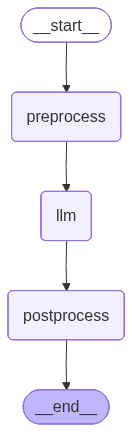

In [8]:
# 그래프 흐름: START → preprocess → llm → postprocess → END
# preprocess: 입력 메시지에 언어 힌트(SystemMessage)를 추가해요
# llm: 모델을 호출하여 응답을 생성해요
# postprocess: 응답에 후처리를 적용해요
from IPython.display import Image, display

display(Image(test_graph.get_graph().draw_mermaid_png()))

In [9]:
# ---------------------------------------------------
# 개별 노드 직접 테스트
# ---------------------------------------------------
# graph.nodes["node_name"].invoke(state)로 노드만 독립 실행해요
from langchain.messages import HumanMessage


def test_preprocess_node():
    """preprocess 노드가 시스템 메시지를 올바르게 추가하는지 테스트해요."""
    # 테스트 상태 준비
    test_state = {
        "messages": [HumanMessage(content="안녕하세요")],
        "language": "영어",
    }

    # preprocess 노드만 독립 실행
    result = test_graph.nodes["preprocess"].invoke(test_state)

    # 검증
    assert "messages" in result, "결과에 messages가 있어야 해요"

    # 추가된 메시지 확인
    added_messages = result["messages"]
    print("preprocess 노드 추가 메시지:", added_messages)

    # SystemMessage가 추가되었는지 확인
    from langchain.messages import SystemMessage
    system_msgs = [m for m in added_messages if isinstance(m, SystemMessage)]
    assert len(system_msgs) > 0, "SystemMessage가 추가되어야 해요"

    # 내용에 언어 정보가 포함되어 있는지 확인
    assert "영어" in system_msgs[0].content, "언어 정보가 포함되어야 해요"

    # [PASS] preprocess 노드 테스트 통과
    print(f"  추가된 시스템 메시지: '{system_msgs[0].content}'")


test_preprocess_node()

preprocess 노드 추가 메시지: [SystemMessage(content='영어로 답변해주세요.', additional_kwargs={}, response_metadata={})]
  추가된 시스템 메시지: '영어로 답변해주세요.'


In [10]:
# ---------------------------------------------------
# 여러 노드 순차 테스트
# ---------------------------------------------------
# 각 노드를 순서대로 테스트하며 상태 변화를 추적해요
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel


def test_node_sequence():
    """노드 순서대로 상태가 올바르게 변환되는지 테스트해요."""
    # 각 노드 테스트마다 새 모델 인스턴스 필요
    fresh_fake_model = GenericFakeChatModel(
        messages=iter([AIMessage(content="파이썬은 훌륭해요")])
    )
    fresh_graph = build_test_graph(fresh_fake_model)

    # 초기 상태
    initial_state = {
        "messages": [HumanMessage(content="파이썬 소개해줘")],
        "language": "한국어",
    }

    # 노드별 상태 변화 추적:
    print(f"초기 메시지 수: {len(initial_state['messages'])}")

    # 1단계: preprocess 노드
    preprocess_result = fresh_graph.nodes["preprocess"].invoke(initial_state)
    print(f"preprocess 후 추가 메시지 수: {len(preprocess_result['messages'])}")

    # 상태 누적 (add_messages 리듀서 시뮬레이션)
    after_preprocess = {
        "messages": initial_state["messages"] + preprocess_result["messages"],
        "language": "한국어",
    }

    # 2단계: llm 노드
    llm_result = fresh_graph.nodes["llm"].invoke(after_preprocess)
    print(f"llm 후 추가 메시지 수: {len(llm_result['messages'])}")
    print(f"LLM 응답: {llm_result['messages'][-1].content}")

    # [PASS] 노드 순차 테스트 통과


test_node_sequence()

초기 메시지 수: 1
preprocess 후 추가 메시지 수: 1
llm 후 추가 메시지 수: 1
LLM 응답: 파이썬은 훌륭해요


## 4. 부분 실행: interrupt_after와 update_state

**부분 실행(Partial Execution)**은 그래프를 특정 노드까지만 실행하고 상태를 검사한 후, 원하면 상태를 수정해서 나머지를 실행할 수 있어요.

이것은 마치 **영화 촬영의 컷(Cut)**과 같아요. 감독이 특정 장면에서 "컷!"을 외치면 촬영이 멈추고, 소품을 바꾸거나 배우 위치를 조정한 뒤 다시 촬영을 이어가는 거예요.

이 기법은 **Human-in-the-Loop** 테스트에 특히 유용해요.

```mermaid
flowchart LR
    A[START] --> B[preprocess]
    B --> C[llm]
    C -.->|interrupt_after| D{상태 검사<br/>컷!}
    D -->|update_state 선택| E[상태 수정]
    D -->|그대로 진행| F[postprocess]
    E --> F
    F --> G[END]

    style C fill:#cce5ff,stroke:#007bff,color:#004085
    style D fill:#fff3cd,stroke:#ffc107,color:#856404
    style E fill:#d4edda,stroke:#28a745,color:#155724
```

> 🔑 **핵심 개념**: `interrupt_after=["node_name"]`을 `invoke`에 전달하면 해당 노드 실행 후 그래프가 일시 중단돼요. 이후 `update_state(config, values, as_node="node_name")`로 상태를 수정하고 `invoke(None, config)`로 나머지를 실행해요.

> ⚠️ **자주 하는 실수**: `interrupt_after`는 **체크포인터가 있어야만 동작**해요. `InMemorySaver`를 연결하지 않으면 중단 지점의 상태를 저장할 수 없어서 에러가 발생해요.

In [11]:
# ---------------------------------------------------
# interrupt_after를 사용한 부분 실행 테스트
# ---------------------------------------------------
# 특정 노드 이후에 실행을 멈추고 상태를 검사해요
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langchain.messages import HumanMessage, AIMessage, SystemMessage


def test_partial_execution_with_interrupt():
    """interrupt_after로 중간 상태를 검사하는 테스트예요."""
    # 체크포인터 필수: interrupt_after는 체크포인터가 있어야 동작해요
    checkpointer = InMemorySaver()

    # 2번 호출 예상: preprocess에서 한 번, 재개 후 한 번
    fake_model = GenericFakeChatModel(
        messages=iter([
            AIMessage(content="파이썬 초기 응답"),
            AIMessage(content="파이썬 재개 후 응답"),
        ])
    )

    # 체크포인터와 함께 그래프 컴파일
    builder = StateGraph(ChatState)

    def preprocess_node(state):
        language = state.get("language", "한국어")
        return {"messages": [SystemMessage(content=f"{language}로 답변해주세요.")]}

    def llm_node(state):
        response = fake_model.invoke(state["messages"])
        return {"messages": [response]}

    def postprocess_node(state):
        last_msg = state["messages"][-1]
        return {"messages": [AIMessage(content=f"[처리완료] {last_msg.content}")]}

    builder.add_node("preprocess", preprocess_node)
    builder.add_node("llm", llm_node)
    builder.add_node("postprocess", postprocess_node)
    builder.add_edge(START, "preprocess")
    builder.add_edge("preprocess", "llm")
    builder.add_edge("llm", "postprocess")
    builder.add_edge("postprocess", END)

    graph_with_checkpointer = builder.compile(checkpointer=checkpointer)

    config = {"configurable": {"thread_id": "partial-exec-001"}}

    # 1단계: llm 노드까지만 실행하고 중단
    # 1단계: llm 노드까지 실행 후 중단
    partial_result = graph_with_checkpointer.invoke(
        {"messages": [HumanMessage(content="파이썬 뭐야?")], "language": "한국어"},
        config=config,
        interrupt_after=["llm"],  # llm 노드 실행 후 중단
    )

    print(f"중단 후 메시지 수: {len(partial_result['messages'])}")
    print("중단 시점 마지막 메시지:", partial_result["messages"][-1].content)

    # 2단계: 상태 검사 및 수정
    # postprocess 전에 llm 응답을 수정해볼 수 있어요
    # 2단계: 상태 수정 없이 나머지 실행
    final_result = graph_with_checkpointer.invoke(
        None,  # None을 전달하면 중단 지점부터 재개해요
        config=config,
    )

    print(f"최종 메시지 수: {len(final_result['messages'])}")
    print("최종 마지막 메시지:", final_result["messages"][-1].content)

    # postprocess가 실행되었는지 확인 ("[처리완료]" 접두사)
    last_content = final_result["messages"][-1].content
    assert "[처리완료]" in last_content, "postprocess 노드가 실행되어야 해요"

    # [PASS] 부분 실행 테스트 통과


test_partial_execution_with_interrupt()

중단 후 메시지 수: 3
중단 시점 마지막 메시지: 파이썬 초기 응답
최종 메시지 수: 4
최종 마지막 메시지: [처리완료] 파이썬 초기 응답


In [12]:
# ---------------------------------------------------
# update_state로 중간 상태를 수정하는 테스트
# ---------------------------------------------------
# 실행 중간에 상태를 수정하고 나머지를 실행해요
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langchain.messages import HumanMessage, AIMessage, SystemMessage


def test_update_state():
    """중간에 상태를 수정하고 나머지 실행을 검증해요."""
    checkpointer = InMemorySaver()

    # 최종 응답만 필요: preprocess, postprocess만 통과하면 돼요
    fake_model = GenericFakeChatModel(
        messages=iter([
            AIMessage(content="원본 LLM 응답"),
        ])
    )

    builder = StateGraph(ChatState)

    def simple_llm(state):
        return {"messages": [fake_model.invoke(state["messages"])]}

    def postprocess(state):
        last = state["messages"][-1]
        return {"messages": [AIMessage(content=f"[최종] {last.content}")]}

    builder.add_node("llm", simple_llm)
    builder.add_node("postprocess", postprocess)
    builder.add_edge(START, "llm")
    builder.add_edge("llm", "postprocess")
    builder.add_edge("postprocess", END)

    graph = builder.compile(checkpointer=checkpointer)
    config = {"configurable": {"thread_id": "update-state-001"}}

    # 1단계: llm 노드까지 실행
    graph.invoke(
        {"messages": [HumanMessage(content="테스트")], "language": "한국어"},
        config=config,
        interrupt_after=["llm"],
    )

    # 2단계: 상태 수정 - llm 응답을 테스트 값으로 교체해요
    # as_node="llm": 마치 llm 노드가 이 상태를 반환한 것처럼 처리해요
    graph.update_state(
        config,
        {"messages": [AIMessage(content="수정된 응답")]},
        as_node="llm",  # 어느 노드의 출력으로 볼지 지정
    )

    # 3단계: 나머지 실행 (postprocess 노드)
    final = graph.invoke(None, config=config)

    last_content = final["messages"][-1].content
    print("최종 메시지:", last_content)

    # 수정된 응답이 postprocess를 거쳤는지 확인
    assert "수정된 응답" in last_content, "수정된 응답이 postprocess를 통과해야 해요"
    assert "[최종]" in last_content, "postprocess 처리가 적용되어야 해요"

    # [PASS] update_state 테스트 통과


test_update_state()

최종 메시지: [최종] 수정된 응답


## 5. 통합 테스트: 실제 LLM 사용

통합 테스트(Integration Test)는 실제 LLM API를 호출해요. 비용이 발생하므로 **구조적 검증(structural assertions)**에 집중해요. 응답의 특정 내용보다는 **형식과 구조**를 검증해요.

### 구조적 검증 원칙

| 검증 대상 | 검증 방법 | 예시 |
|-----------|-----------|------|
| 응답 타입 | `isinstance(msg, AIMessage)` | AIMessage인지 확인 |
| 도구 선택 | `msg.tool_calls[0]["name"]` | 올바른 도구를 선택했는지 |
| 인자 구조 | `"city" in tool_call["args"]` | 필수 인자가 있는지 |
| 응답 형식 | `len(content) > 0` | 응답이 비어있지 않은지 |

> 💡 **실무 팁**: 통합 테스트에서 응답 내용을 정확히 검증하려 하지 마세요. "서울"이라는 단어가 응답에 있는지 확인하는 것보다, 모델이 날씨 도구를 호출하는 구조 자체를 검증하는 게 더 신뢰할 수 있어요.

> ⚠️ **자주 하는 실수**: 통합 테스트를 기본 테스트 실행에 포함시키면 매번 API 비용이 발생해요. 반드시 `pytest.mark.integration`으로 마커를 지정하고 별도 실행하도록 분리해요.

In [13]:
# ---------------------------------------------------
# pytest 스타일 통합 테스트 예시
# ---------------------------------------------------
# 실제 파일로 저장해서 pytest로 실행하는 패턴을 보여줘요
# (이 셀은 노트북에서 직접 실행하는 예시예요)

integration_test_code = '''
# tests/test_agent_integration.py

import pytest
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver


@tool
def get_weather(city: str) -> str:
    """도시의 현재 날씨를 조회해요."""
    weather_data = {"서울": "맑음, 18도", "부산": "흐림, 22도"}
    return weather_data.get(city, f"{city}: 데이터 없음")


@pytest.mark.integration  # 통합 테스트 마커: 기본 실행에서 제외해요
def test_weather_agent_tool_selection():
    """날씨 에이전트가 올바른 도구를 선택하는지 통합 테스트해요."""
    # 실제 모델 사용: 비용 최소화를 위해 gpt-4o-mini 사용
    model = init_chat_model("openai:gpt-4o-mini")
    checkpointer = InMemorySaver()

    agent = create_agent(
        model=model,
        tools=[get_weather],
        checkpointer=checkpointer,
        system_prompt="날씨 정보를 제공하는 어시스턴트예요.",
    )

    config = {"configurable": {"thread_id": "integration-001"}}
    result = agent.invoke(
        {"messages": [HumanMessage(content="서울 날씨 알려줘")]},
        config=config,
    )

    messages = result["messages"]

    # 구조적 검증 1: 도구 호출 메시지가 있는지
    tool_call_msgs = [
        m for m in messages
        if isinstance(m, AIMessage) and getattr(m, "tool_calls", None)
    ]
    assert len(tool_call_msgs) > 0, "도구 호출 메시지가 있어야 해요"

    # 구조적 검증 2: get_weather 도구가 선택되었는지
    tool_names = [tc["name"] for tc in tool_call_msgs[0].tool_calls]
    assert "get_weather" in tool_names, "get_weather 도구가 선택되어야 해요"

    # 구조적 검증 3: city 인자가 있는지 (내용은 검증 안 함)
    weather_call = next(
        tc for tc in tool_call_msgs[0].tool_calls if tc["name"] == "get_weather"
    )
    assert "city" in weather_call["args"], "city 인자가 있어야 해요"

    # 구조적 검증 4: ToolMessage가 있는지 (실제 도구 실행 결과)
    tool_msgs = [m for m in messages if isinstance(m, ToolMessage)]
    assert len(tool_msgs) > 0, "ToolMessage가 있어야 해요"

    # 구조적 검증 5: 최종 응답이 AIMessage인지
    assert isinstance(messages[-1], AIMessage), "최종 응답은 AIMessage여야 해요"
    assert len(messages[-1].content) > 0, "최종 응답이 비어있으면 안 돼요"
'''

# 통합 테스트 코드 패턴:
print(integration_test_code)


# tests/test_agent_integration.py

import pytest
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver


@tool
def get_weather(city: str) -> str:
    """도시의 현재 날씨를 조회해요."""
    weather_data = {"서울": "맑음, 18도", "부산": "흐림, 22도"}
    return weather_data.get(city, f"{city}: 데이터 없음")


@pytest.mark.integration  # 통합 테스트 마커: 기본 실행에서 제외해요
def test_weather_agent_tool_selection():
    """날씨 에이전트가 올바른 도구를 선택하는지 통합 테스트해요."""
    # 실제 모델 사용: 비용 최소화를 위해 gpt-4o-mini 사용
    model = init_chat_model("openai:gpt-4o-mini")
    checkpointer = InMemorySaver()

    agent = create_agent(
        model=model,
        tools=[get_weather],
        checkpointer=checkpointer,
        system_prompt="날씨 정보를 제공하는 어시스턴트예요.",
    )

    config = {"configurable": {"thread_id": "integration-001"}}
    result = agent.invoke(
     

In [14]:
# ---------------------------------------------------
# 노트북에서 통합 테스트 직접 실행 예시
# ---------------------------------------------------
# 실제 API를 호출해요 (비용 발생)
# 주의: 이 셀은 OPENAI_API_KEY가 설정되어 있어야 해요
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver


def run_integration_test():
    """실제 LLM을 사용한 통합 테스트예요."""
    # 비용 절감: gpt-4o-mini 사용
    model = init_chat_model("openai:gpt-4o-mini")
    checkpointer = InMemorySaver()

    agent = create_agent(
        model=model,
        tools=tools,  # 앞에서 정의한 get_weather, calculate
        checkpointer=checkpointer,
        system_prompt="도움이 되는 AI 어시스턴트예요. 필요한 경우 도구를 사용해요.",
    )

    config = {"configurable": {"thread_id": "integration-test-live"}}

    # 통합 테스트 실행 중... (실제 API 호출)
    result = agent.invoke(
        {"messages": [HumanMessage(content="서울 날씨 알려줘")]},
        config=config,
    )

    messages = result["messages"]

    # 메시지 흐름:
    for i, msg in enumerate(messages):
        msg_type = type(msg).__name__
        if isinstance(msg, AIMessage) and msg.tool_calls:
            print(f"  [{i}] {msg_type}: [도구 호출] {[tc['name'] for tc in msg.tool_calls]}")
        elif isinstance(msg, ToolMessage):
            print(f"  [{i}] {msg_type}: {msg.content[:50]}")
        else:
            content = str(msg.content)[:60] if msg.content else "(empty)"
            print(f"  [{i}] {msg_type}: {content}")

    # 구조적 검증
    assert isinstance(messages[-1], AIMessage), "최종 응답은 AIMessage여야 해요"
    assert len(messages[-1].content) > 0, "응답이 비어있으면 안 돼요"

    # [PASS] 통합 테스트 통과
    print(f"최종 응답: {messages[-1].content}")


run_integration_test()

  [0] HumanMessage: 서울 날씨 알려줘
  [1] AIMessage: [도구 호출] ['get_weather']
  [2] ToolMessage: 맑음, 18°C
  [3] AIMessage: 현재 서울의 날씨는 맑고, 기온은 18°C입니다.
최종 응답: 현재 서울의 날씨는 맑고, 기온은 18°C입니다.


## 6. pytest 설정: 비용 효율적인 CI/CD 구성

팀 프로젝트에서는 단위 테스트와 통합 테스트를 분리해야 해요. `pytest.ini` 또는 `pyproject.toml`로 기본 실행에서 통합 테스트를 제외할 수 있어요.

> 💡 **실무 팁**: CI/CD 파이프라인에서 PR 체크는 단위 테스트만 실행하고, 메인 브랜치 병합 시 통합 테스트를 실행하는 전략이 비용 효율적이에요. 이렇게 하면 개발자가 빠른 피드백을 받으면서도 통합 품질을 보장할 수 있어요.

### pytest 설정 파일 예시

실제 프로젝트에서 사용하는 pytest 설정이에요.

**pytest.ini** (또는 pyproject.toml의 `[tool.pytest.ini_options]`):

```ini
[pytest]
# 기본 실행에서 integration 마커가 붙은 테스트를 제외해요
# 통합 테스트 실행: pytest -m integration
# 단위 테스트만 실행: pytest (기본)
# 모든 테스트 실행: pytest -m "" 또는 pytest --run-integration
addopts = -m "not integration"

# 커스텀 마커 정의 (마커 미등록 경고 방지)
markers =
    integration: 실제 LLM API를 호출하는 통합 테스트 (비용 발생)
    slow: 실행 시간이 긴 테스트
```

**pyproject.toml** 방식:

```toml
[tool.pytest.ini_options]
addopts = "-m 'not integration'"
markers = [
    "integration: 실제 LLM API를 호출하는 통합 테스트 (비용 발생)",
    "slow: 실행 시간이 긴 테스트",
]
```

### 전체 테스트 파일 구조 예시

실제 프로젝트에서 권장하는 테스트 파일 구조예요.

```
tests/
├── conftest.py              # 공통 fixture, 가짜 모델 factory
├── unit/
│   ├── test_nodes.py        # 개별 노드 단위 테스트
│   ├── test_tools.py        # 도구 함수 단위 테스트
│   └── test_state.py        # 상태 변환 단위 테스트
└── integration/
    ├── test_agent_e2e.py    # 에이전트 종단간 통합 테스트
    └── test_tools_live.py   # 실제 도구 호출 통합 테스트
```

**conftest.py** 내용:

```python
# tests/conftest.py

import pytest
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import AIMessage


@pytest.fixture
def fresh_checkpointer():
    """각 테스트마다 새로운 체크포인터를 제공해요."""
    return InMemorySaver()


def make_fake_model(*responses: str):
    """텍스트 응답 목록으로 가짜 모델을 생성해요."""
    messages = iter([AIMessage(content=r) for r in responses])
    return GenericFakeChatModel(messages=messages)


@pytest.fixture
def single_response_model():
    """단일 응답 가짜 모델 fixture예요."""
    return make_fake_model("테스트 응답")
```

## 7. 실전 패턴: 종합 테스트 시나리오

실제 프로젝트에서 자주 쓰이는 테스트 패턴들을 정리해요.

> 🎯 **강의 포인트**: 에이전트 테스트에서 가장 중요한 것은 **행동(behavior)을 테스트하는 것이지 구현(implementation)을 테스트하는 게 아니에요**. "모델이 특정 토큰을 생성하는지" 대신 "올바른 도구를 선택하는지", "상태가 올바르게 업데이트되는지"를 검증해요.

In [15]:
# ---------------------------------------------------
# 패턴 1: 멀티턴 대화 테스트
# ---------------------------------------------------
# 여러 메시지 교환 후 상태가 올바르게 유지되는지 검증해요
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, AIMessage


def test_multi_turn_conversation():
    """멀티턴 대화에서 대화 히스토리가 유지되는지 테스트해요."""
    checkpointer = InMemorySaver()

    # 3번의 대화 교환을 위한 응답 준비
    # FakeChatModelWithTools: bind_tools()를 지원해요
    fake_model = FakeChatModelWithTools(
        messages=iter([
            AIMessage(content="안녕하세요! 무엇을 도와드릴까요?"),
            AIMessage(content="파이썬은 훌륭한 언어예요."),
            AIMessage(content="네, 이전에 파이썬에 대해 이야기했죠."),
        ])
    )

    agent = create_agent(
        model=fake_model,
        tools=tools,
        checkpointer=checkpointer,
        system_prompt="친절한 AI 어시스턴트예요.",
    )

    # 동일한 thread_id 사용: 대화 히스토리가 유지돼요
    config = {"configurable": {"thread_id": "multi-turn-001"}}

    # 1번째 메시지
    result1 = agent.invoke(
        {"messages": [HumanMessage(content="안녕")]},
        config=config
    )
    print(f"1번째 응답: {result1['messages'][-1].content}")

    # 2번째 메시지 (히스토리가 있으니 이어서)
    result2 = agent.invoke(
        {"messages": [HumanMessage(content="파이썬 뭐야?")]},
        config=config
    )
    print(f"2번째 응답: {result2['messages'][-1].content}")

    # 3번째 메시지
    result3 = agent.invoke(
        {"messages": [HumanMessage(content="아까 뭐라고 했었지?")]},
        config=config
    )
    print(f"3번째 응답: {result3['messages'][-1].content}")

    # 멀티턴 검증: 메시지가 누적되어야 해요
    # 각 turn마다: 이전 HumanMessage + AIMessage + 새 HumanMessage + AIMessage
    total_messages = result3["messages"]
    human_msgs = [m for m in total_messages if isinstance(m, HumanMessage)]
    assert len(human_msgs) == 3, f"Human 메시지 3개여야 해요 (실제: {len(human_msgs)})"

    print(f"\n총 메시지 수: {len(total_messages)}")
    # [PASS] 멀티턴 대화 테스트 통과


test_multi_turn_conversation()

1번째 응답: 안녕하세요! 무엇을 도와드릴까요?
2번째 응답: 파이썬은 훌륭한 언어예요.
3번째 응답: 네, 이전에 파이썬에 대해 이야기했죠.

총 메시지 수: 6


In [16]:
# ---------------------------------------------------
# 패턴 2: 도구 선택 정확도 단위 테스트
# ---------------------------------------------------
# 올바른 도구가 올바른 인자로 호출되었는지 검증해요
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, AIMessage


def assert_tool_called_with(messages, tool_name: str, **expected_args):
    """메시지 목록에서 특정 도구가 특정 인자로 호출되었는지 검증해요."""
    tool_call_msgs = [
        m for m in messages
        if isinstance(m, AIMessage) and getattr(m, 'tool_calls', None)
    ]

    assert len(tool_call_msgs) > 0, f"{tool_name} 도구 호출 메시지가 없어요"

    # 도구 이름 확인
    all_tool_names = [
        tc['name']
        for msg in tool_call_msgs
        for tc in msg.tool_calls
    ]
    assert tool_name in all_tool_names, f"{tool_name} 도구가 호출되지 않았어요. 호출된 도구: {all_tool_names}"

    # 인자 확인
    for msg in tool_call_msgs:
        for tc in msg.tool_calls:
            if tc['name'] == tool_name:
                for arg_name, arg_value in expected_args.items():
                    assert arg_name in tc['args'], f"{tool_name}에 {arg_name} 인자가 없어요"
                    if arg_value is not None:
                        assert tc['args'][arg_name] == arg_value, \
                            f"{arg_name}의 값이 '{arg_value}'여야 해요 (실제: {tc['args'][arg_name]})"


def test_weather_tool_called_correctly():
    """날씨 도구가 올바른 city 인자로 호출되는지 테스트해요."""
    checkpointer = InMemorySaver()

    # FakeChatModelWithTools: bind_tools()를 지원해요
    fake_model = FakeChatModelWithTools(
        messages=iter([
            AIMessage(
                content="",
                tool_calls=[{
                    "id": "call_001",
                    "name": "get_weather",
                    "args": {"city": "부산"},
                    "type": "tool_call",
                }]
            ),
            AIMessage(content="부산 날씨는 흐림이에요."),
        ])
    )

    agent = create_agent(
        model=fake_model,
        tools=tools,
        checkpointer=checkpointer,
        system_prompt="날씨 어시스턴트예요.",
    )

    config = {"configurable": {"thread_id": "tool-check-001"}}
    result = agent.invoke(
        {"messages": [HumanMessage(content="부산 날씨 알려줘")]},
        config=config
    )

    # 커스텀 검증 함수 사용
    assert_tool_called_with(
        result["messages"],
        tool_name="get_weather",
        city="부산",  # 정확한 값 검증
    )

    # [PASS] 도구 선택 정확도 테스트 통과
    print(f"  get_weather(city='부산') 호출 확인됨")


test_weather_tool_called_correctly()

  get_weather(city='부산') 호출 확인됨


In [17]:
# ============================================================
# TODO: 나만의 테스트 시나리오 작성해보기
# 힌트: FakeChatModelWithTools로 calculate 도구를 호출하는 시나리오를 설계해요
#       예: "3 + 5 계산해줘"라는 입력에 calculate(expression="3 + 5")가 호출되는지
# 예상 결과: [PASS] 메시지와 함께 테스트가 통과해야 해요
# ============================================================

from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, AIMessage


def test_calculate_tool():
    """TODO: 계산기 도구 테스트를 구현해보세요."""
    checkpointer = InMemorySaver()

    # TODO: 계산기 도구를 호출하는 fake_model을 설계해요
    # 힌트: AIMessage의 tool_calls에 calculate 도구와 expression 인자를 넣어요
    # FakeChatModelWithTools를 사용해요 (bind_tools() 지원)
    fake_model = FakeChatModelWithTools(
        messages=iter([
            # TODO: 여기에 도구 호출 AIMessage를 작성해요
            AIMessage(content="3 + 5 = 8이에요."),
        ])
    )

    agent = create_agent(
        model=fake_model,
        tools=tools,
        checkpointer=checkpointer,
        system_prompt="계산기 어시스턴트예요.",
    )

    config = {"configurable": {"thread_id": "calc-test-001"}}
    result = agent.invoke(
        {"messages": [HumanMessage(content="3 + 5 계산해줘")]},
        config=config
    )

    # TODO: assert_tool_called_with로 calculate가 올바르게 호출됐는지 검증해요
    print("테스트 결과:", result["messages"][-1].content)
    # [TODO] 도구 호출 검증 로직을 추가해보세요


test_calculate_tool()

테스트 결과: 3 + 5 = 8이에요.


## 8. 테스트 실행 명령어 정리

실제 프로젝트에서 사용하는 pytest 실행 명령어를 정리해요.

In [18]:
# ---------------------------------------------------
# pytest 실행 명령어 참고용 출력
# ---------------------------------------------------
# 터미널에서 실행하는 명령어예요 (노트북에서는 참고만 해요)

commands = {
    "단위 테스트만 실행 (기본, 비용 없음)": "pytest tests/unit/",
    "통합 테스트만 실행 (비용 발생)": "pytest tests/integration/ -m integration",
    "모든 테스트 실행": 'pytest tests/ -m ""',
    "특정 파일 실행": "pytest tests/unit/test_nodes.py",
    "특정 함수 실행": "pytest tests/unit/test_nodes.py::test_preprocess_node",
    "자세한 출력": "pytest -v tests/unit/",
    "실패 시 즉시 중단": "pytest -x tests/",
    "커버리지 확인": "pytest --cov=src tests/unit/",
}

# pytest 실행 명령어 참고
# ============================================================
for desc, cmd in commands.items():
    print(f"\n[{desc}]")
    print(f"  $ {cmd}")


[단위 테스트만 실행 (기본, 비용 없음)]
  $ pytest tests/unit/

[통합 테스트만 실행 (비용 발생)]
  $ pytest tests/integration/ -m integration

[모든 테스트 실행]
  $ pytest tests/ -m ""

[특정 파일 실행]
  $ pytest tests/unit/test_nodes.py

[특정 함수 실행]
  $ pytest tests/unit/test_nodes.py::test_preprocess_node

[자세한 출력]
  $ pytest -v tests/unit/

[실패 시 즉시 중단]
  $ pytest -x tests/

[커버리지 확인]
  $ pytest --cov=src tests/unit/


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **3단계 테스트 전략**: 단위 테스트(빠름/무료) → 통합 테스트(느림/유료) → 평가(가장 느림/유료)의 피라미드 전략으로 비용과 속도의 균형을 맞춰요
- **GenericFakeChatModel**: `iter([AIMessage(...), ...])` 패턴으로 LLM 응답을 미리 정의해 API 비용 없이 에이전트 로직을 테스트해요. `tool_calls`를 포함한 AIMessage로 도구 호출 시나리오도 시뮬레이션 가능해요
- **InMemorySaver**: 테스트용 체크포인터. 각 테스트마다 **새 인스턴스**를 생성해 테스트 간 상태 오염을 막아요
- **개별 노드 테스트**: `graph.nodes["name"].invoke(state)`로 특정 노드만 독립 실행해 노드 로직을 격리 검증해요
- **부분 실행**: `interrupt_after=["node_name"]`으로 특정 노드에서 중단 후, `update_state()`로 상태 수정, `invoke(None)`으로 재개하는 패턴이에요
- **구조적 검증**: 통합 테스트에서 LLM 응답 내용이 아닌 **타입, 도구명, 인자 구조**를 검증해 비결정성에 강한 테스트를 작성해요
- **pytest 설정**: `addopts = -m "not integration"`으로 기본 실행에서 통합 테스트를 제외해 CI/CD 비용을 절감해요

### 이전 Part와의 연결

| 이 노트북에서 사용한 개념 | 배운 곳 |
|--------------------------|---------|
| `create_agent`, 도구 바인딩 | Part 5 에이전트 개발 |
| `InMemorySaver`, 체크포인터 | Part 2-07 Memory-Checkpointer, Part 7 |
| `interrupt_after`, `update_state` | Part 2-08 Human-in-the-Loop |
| `StateGraph`, 노드, 엣지 | Part 2-04 StateGraph Basics |

## 다음 노트북 예고

다음 `02-Agent-Evaluation.ipynb`에서는 **LangSmith 기반 평가**를 배워요. 테스트가 "버그를 잡는 것"이라면 평가는 **"품질을 측정하는 것"**이에요. `openevals`의 LLM-as-Judge로 응답 정확도를, `agentevals`의 궤적 매처로 도구 호출 순서를 검증하고, `client.evaluate()`로 데이터셋 기반 전체 평가 파이프라인을 구성해요.